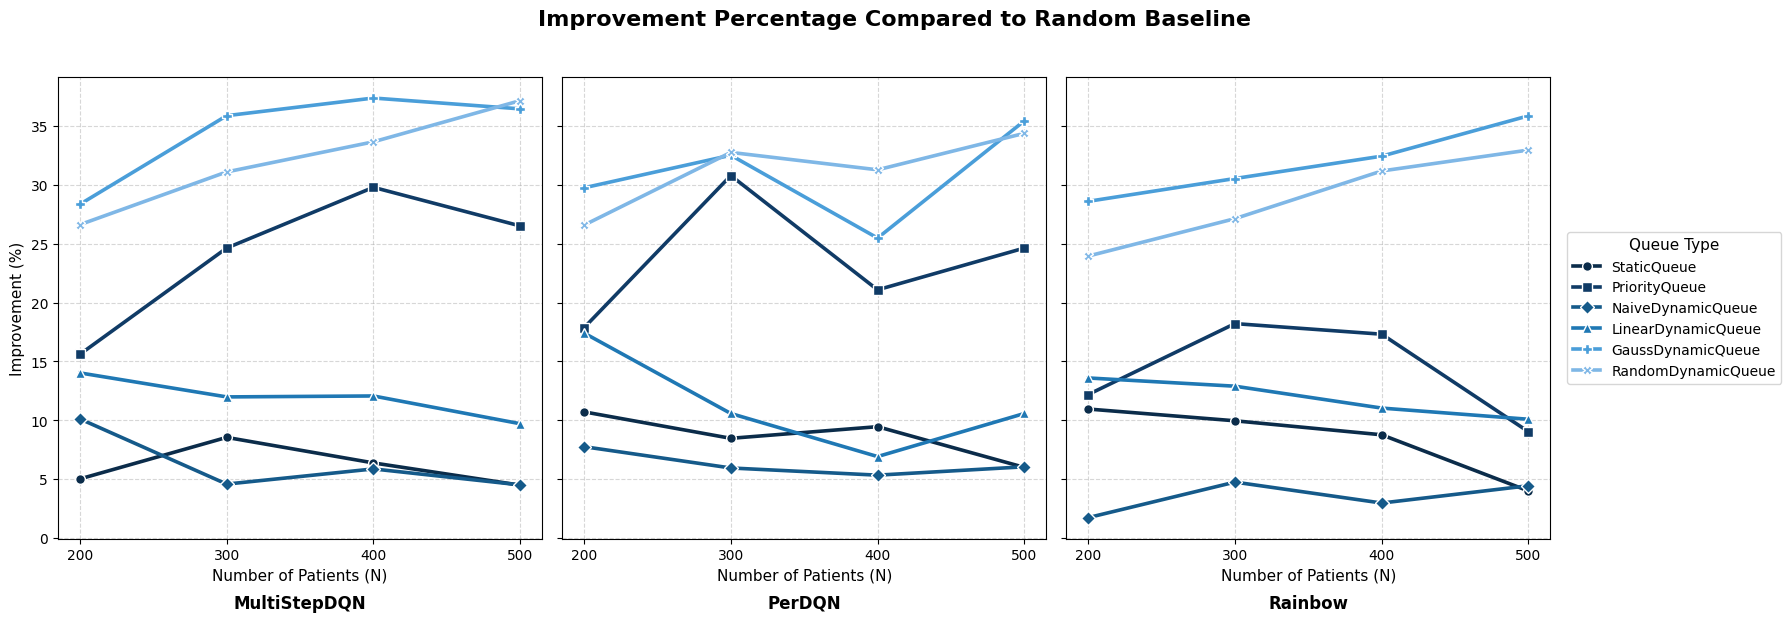

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Data
# =========================
patients = [200, 300, 400, 500]

data = {
    "StaticQueue": {
        "MultiStepDQN": [5.01, 8.54, 6.37, 4.48],
        "PerDQN": [10.71, 8.46, 9.45, 5.99],
        "Rainbow": [10.95, 9.95, 8.76, 3.99]
    },
    "PriorityQueue": {
        "MultiStepDQN": [15.6, 24.63, 29.79, 26.51],
        "PerDQN": [17.86, 30.79, 21.08, 24.63],
        "Rainbow": [12.18, 18.21, 17.31, 9.02]
    },
    "NaiveDynamicQueue": {
        "MultiStepDQN": [10.11, 4.57, 5.86, 4.5],
        "PerDQN": [7.75, 5.94, 5.33, 6.04],
        "Rainbow": [1.72, 4.74, 2.96, 4.43]
    },
    "LinearDynamicQueue": {
        "MultiStepDQN": [14.02, 11.98, 12.06, 9.7],
        "PerDQN": [17.41, 10.57, 6.91, 10.57],
        "Rainbow": [13.59, 12.89, 11.03, 10.08]
    },
    "GaussDynamicQueue": {
        "MultiStepDQN": [28.35, 35.88, 37.38, 36.46],
        "PerDQN": [29.75, 32.52, 25.48, 35.44],
        "Rainbow": [28.6, 30.54, 32.44, 35.87]
    },
    "RandomDynamicQueue": {
        "MultiStepDQN": [26.62, 31.1, 33.66, 37.16],
        "PerDQN": [26.58, 32.76, 31.28, 34.38],
        "Rainbow": [23.95, 27.13, 31.18, 32.96]
    }
}

algorithms = ["MultiStepDQN", "PerDQN", "Rainbow"]
queues = list(data.keys())

# =========================
# 2. Muted pastel colors (đậm hơn)
# =========================
queue_color = {
    "StaticQueue":        "#0B3D2E",  # very dark green (almost black)
    "PriorityQueue":      "#145A32",  # dark green
    "NaiveDynamicQueue":  "#1E8449",  # medium-dark green
    "LinearDynamicQueue": "#27AE60",  # medium green
    "GaussDynamicQueue":  "#52BE80",  # light green (still visible)
    "RandomDynamicQueue": "#7DCEA0",  # lightest green (NOT white)
}


queue_color = {
    "StaticQueue":        "#0B2C4A",  # very dark blue (almost black)
    "PriorityQueue":      "#103B66",  # dark blue
    "NaiveDynamicQueue":  "#155A8A",  # medium-dark blue
    "LinearDynamicQueue": "#1F78B4",  # medium blue
    "GaussDynamicQueue":  "#4A9ED9",  # light blue (still strong)
    "RandomDynamicQueue": "#7FB7E6",  # lightest blue (NOT white)
}

# =========================
# 3. Subplots
# =========================
fig, axes = plt.subplots(
    1, 3, figsize=(18, 6),
    sharex=True, sharey=True
)

fig.suptitle(
    "Improvement Percentage Compared to Random Baseline",
    fontsize=16, fontweight="bold", y=1.03
)

for ax, algo in zip(axes, algorithms):
    for q in queues:
        ax.plot(
            patients,
            data[q][algo],
            label=q,
            color=queue_color[q],
            marker=queue_marker[q],
            linewidth=2.6,
            markersize=7,
            markeredgecolor="white",
            markeredgewidth=1.0,
        )

    ax.set_xticks(patients)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.set_xlabel("Number of Patients (N)", fontsize=11)

    # Algorithm name dưới subplot
    ax.text(
        0.5, -0.12, algo,
        transform=ax.transAxes,
        ha="center", va="top",
        fontsize=12, fontweight="bold"
    )

# Y-label chỉ cần 1 subplot
axes[0].set_ylabel("Improvement (%)", fontsize=11)

# =========================
# 4. Legend sát subplot cuối
# =========================
handles, labels = axes[0].get_legend_handles_labels()

axes[-1].legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Queue Type",
    fontsize=10,
    title_fontsize=11,
)

plt.tight_layout()

plt.savefig(
    "improvement_vs_random_baseline.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

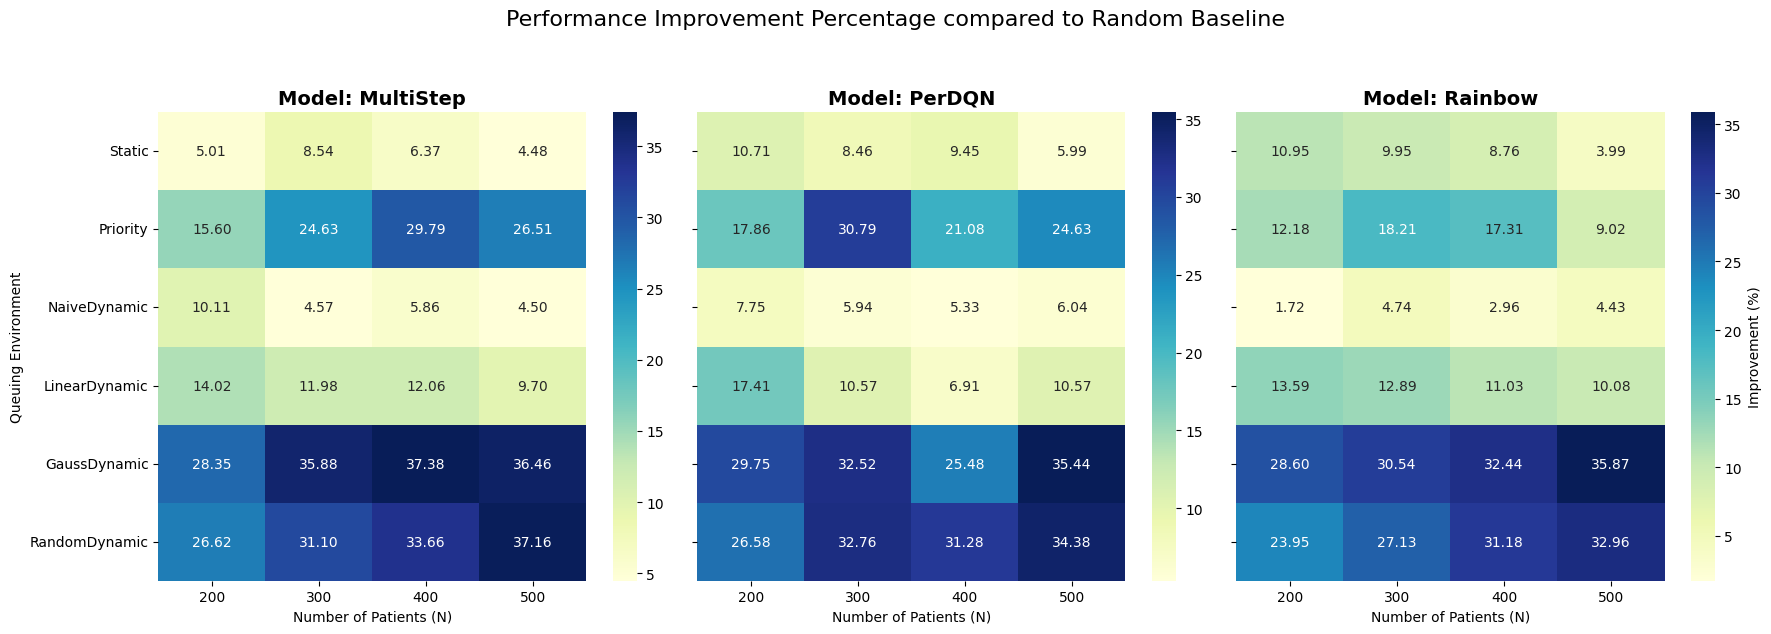

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Chuẩn bị dữ liệu 
data = {
    'Environment': ['Static', 'Static', 'Static', 'Priority', 'Priority', 'Priority', 
                    'NaiveDynamic', 'NaiveDynamic', 'NaiveDynamic', 'LinearDynamic', 'LinearDynamic', 'LinearDynamic',
                    'GaussDynamic', 'GaussDynamic', 'GaussDynamic', 'RandomDynamic', 'RandomDynamic', 'RandomDynamic'],
    'Model': ['MultiStep', 'PerDQN', 'Rainbow'] * 6,
    '200': [5.01, 10.71, 10.95, 15.60, 17.86, 12.18, 10.11, 7.75, 1.72, 14.02, 17.41, 13.59, 28.35, 29.75, 28.60, 26.62, 26.58, 23.95],
    '300': [8.54, 8.46, 9.95, 24.63, 30.79, 18.21, 4.57, 5.94, 4.74, 11.98, 10.57, 12.89, 35.88, 32.52, 30.54, 31.10, 32.76, 27.13],
    '400': [6.37, 9.45, 8.76, 29.79, 21.08, 17.31, 5.86, 5.33, 2.96, 12.06, 6.91, 11.03, 37.38, 25.48, 32.44, 33.66, 31.28, 31.18],
    '500': [4.48, 5.99, 3.99, 26.51, 24.63, 9.02, 4.50, 6.04, 4.43, 9.70, 10.57, 10.08, 36.46, 35.44, 35.87, 37.16, 34.38, 32.96]
}

df = pd.DataFrame(data)
df_melted = df.melt(id_vars=['Environment', 'Model'], var_name='Patients', value_name='Improvement')

models = ['MultiStep', 'PerDQN', 'Rainbow']
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, model in enumerate(models):
    # Lọc dữ liệu cho từng model và pivot để tạo ma trận heatmap
    model_data = df[df['Model'] == model].set_index('Environment')[['200', '300', '400', '500']]
    
    sns.heatmap(model_data, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[i], 
                cbar_kws={'label': 'Improvement (%)'} if i == 2 else None)
    
    axes[i].set_title(f'Model: {model}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Number of Patients (N)')
    if i == 0:
        axes[i].set_ylabel('Queuing Environment')
    else:
        axes[i].set_ylabel('')

plt.suptitle('Performance Improvement Percentage compared to Random Baseline', fontsize=16, y=1.05)
plt.tight_layout()

plt.savefig(
    "improvement_vs_random_baseline.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()